In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# inputs
CL = 0.95
A = 28 # target mass Si
# annual modulation fitting constants
c1 = 0.751
c2 = 0.561
m_T = A*0.938 #[GeV]
# most likely speed
v_0 = 230 #[km s-1]

# recoil energy bounds for detector, E1 = min, E2 = max
E1 = 1*10**-6 #in GeV
E2 = 100 #in GeV 

# the length and mass of the experiment data-taking
DAQday = 1
DAQkg = 1

In [ ]:
def get_spectrum(m_D = 1, xs = 10**-1, A = 28, v_0 = 230,  E1 = 0.1*10**-6, E2 = 50, CL = 0.95, 
                      flag_nuclear_form_factor = True, nbins = 12):

    m_T = A*0.938 #[GeV]
    bin_edges = np.linspace(E1, E1*5, nbins+1)
    bin_centers = [(bin_edges[i+1] + bin_edges[i]) / 2 for i in range(nbins)]
    binwidth = bin_edges[1]- bin_edges[0]

    # most probable incident energy of the dark matter [GeV]
    E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
    r = 4*m_D*m_T/(m_D+m_T)**2
    R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
    if flag_nuclear_form_factor == True:
        k = c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
    else:
        k = c2/(E0*r) 

    bin_contents = np.zeros(nbins)
    for i in range(nbins):
         bin_contents[i] = c1 * R0/E0/r/k * (np.exp(-k*bin_edges[i]) - np.exp(-k*bin_edges[i+1]))
    

    return bin_contents, binwidth, bin_centers

In [15]:
data = np.random.normal(loc=0.03, scale=0.01, size=12)
error = np.ones(12)*0.001

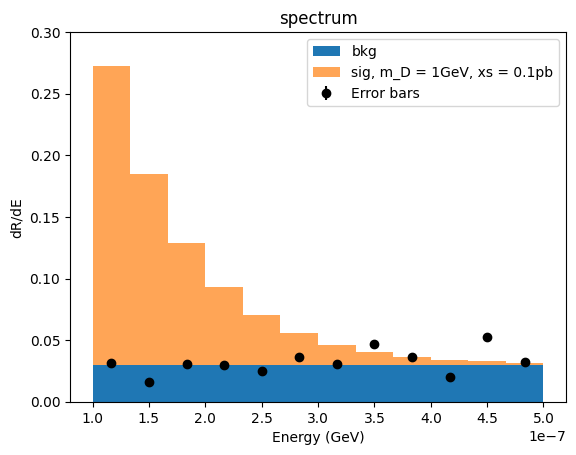

In [16]:
bin_contents_sig1, binwidth, bin_centers = get_spectrum()
bin_contents_bkg = np.ones(12)*0.03

plt.bar(bin_centers, bin_contents_bkg,width=binwidth, label='bkg')  # 在第一组数据上绘制第二组数据
plt.bar(bin_centers, bin_contents_sig1,bottom=bin_contents_bkg, width=binwidth, alpha=0.7, label = "sig, m_D = 1GeV, xs = 0.1pb")

#data
plt.errorbar(bin_centers, data, yerr=error, fmt='o', color='black', label='Error bars')  # 带误差条的数据点

plt.xlabel('Energy (GeV)')
plt.ylabel('dR/dE')
plt.title('spectrum')
plt.legend()
plt.ylim(0,0.3)

plt.show()

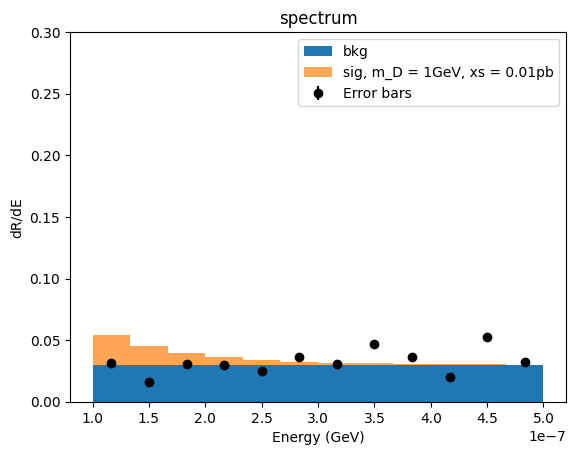

In [17]:
bin_contents_sig2, binwidth, bin_centers = get_spectrum(xs = 0.01)
bin_contents_bkg = np.ones(12)*0.03

plt.bar(bin_centers, bin_contents_bkg,width=binwidth, label='bkg') 
plt.bar(bin_centers, bin_contents_sig2,bottom=bin_contents_bkg, width=binwidth, alpha=0.7, label = "sig, m_D = 1GeV, xs = 0.01pb")

#data
plt.errorbar(bin_centers, data, yerr=error, fmt='o', color='black', label='Error bars') 

plt.xlabel('Energy (GeV)')
plt.ylabel('dR/dE')
plt.title('spectrum')
plt.legend()
plt.ylim(0,0.3)

plt.show()

In [36]:
# scan
def calculate_chi2(data, error, model):
    chi2 = 0
    for i in range(len(data)):
        chi2 += (data[i]-model[i])**2/error[i]
    return chi2


mass = np.linspace(1, 10, 100)
crosssection = np.linspace(0.0001, 0.001, 100)

chi2 = np.zeros([100,100])

for i, m_D in enumerate(mass):
    for j, xs in enumerate(crosssection):
        bin_contents_sig, binwidth, bin_centers = get_spectrum(m_D=m_D, xs = xs)
        model = bin_contents_bkg + bin_contents_sig2
        chi2[i,j] = calculate_chi2(data, error, model = bin_contents_bkg + bin_contents_sig)


print(chi2)



[[1.19865138 1.19893623 1.19922271 ... 1.23390359 1.23434722 1.2347925 ]
 [1.19857346 1.19885204 1.19913239 ... 1.23384835 1.23429886 1.23475115]
 [1.19826307 1.19851358 1.19876589 ... 1.23093527 1.23136021 1.23178694]
 ...
 [1.1955222  1.19551276 1.19550332 ... 1.19461019 1.19460083 1.19459147]
 [1.19552435 1.1955151  1.19550586 ... 1.19463112 1.19462195 1.19461278]
 [1.19552643 1.19551737 1.19550832 ... 1.19465143 1.19464244 1.19463346]]


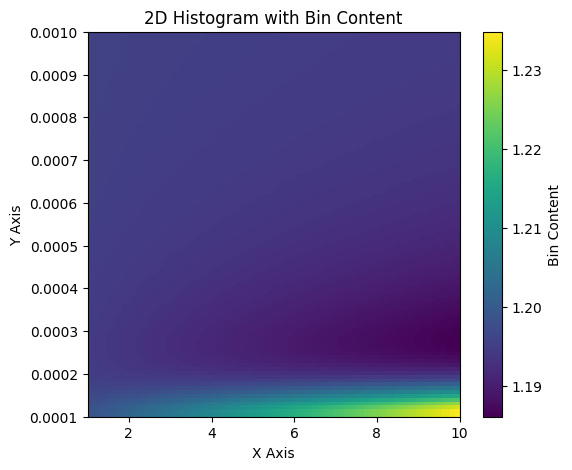

In [37]:

x_bins = mass  
y_bins = crosssection 
bin_contents = chi2
                        

plt.figure(figsize=(6, 5))
plt.imshow(bin_contents, origin='lower', cmap='viridis', 
           extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]], aspect='auto')

plt.colorbar(label='Bin Content')

plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('2D Histogram with Bin Content')
plt.show()


In [ ]:
min_index = np.unravel_index(np.argmin(chi2), chi2.shape)
min_index

(20, 99)

In [48]:
chi2[:,99]

array([1.2347925 , 1.23475115, 1.23178694, 1.22703358, 1.22145929,
       1.21576038, 1.21037493, 1.20554034, 1.2013555 , 1.19783206,
       1.19493175, 1.19259141, 1.19073858, 1.18930079, 1.18821047,
       1.18740723, 1.18683868, 1.18646015, 1.18623416, 1.18612955,
       1.18612064, 1.18618641, 1.18630974, 1.18647674, 1.18667621,
       1.18689914, 1.18713834, 1.18738805, 1.18764375, 1.18790185,
       1.18815955, 1.18841472, 1.18866568, 1.18891122, 1.18915041,
       1.18938263, 1.18960744, 1.18982457, 1.19003388, 1.19023536,
       1.19042905, 1.19061505, 1.19079354, 1.19096469, 1.19112873,
       1.1912859 , 1.19143643, 1.19158059, 1.19171861, 1.19185077,
       1.1919773 , 1.19209846, 1.19221447, 1.19232559, 1.19243202,
       1.19253399, 1.1926317 , 1.19272535, 1.19281514, 1.19290124,
       1.19298383, 1.19306308, 1.19313914, 1.19321216, 1.19328229,
       1.19334966, 1.1934144 , 1.19347663, 1.19353647, 1.19359404,
       1.19364942, 1.19370273, 1.19375406, 1.19380349, 1.19385